In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, LogisticRegression, OneVsRest, LinearSVC
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression

# 1. Iniciar la sesión de Spark para la Semana 12
spark = SparkSession.builder.appName("Semana12_Supervisados_Renato").getOrCreate()

# 2. Leer los datos nativos persistidos en la Semana 10
ruta_datos = "/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans"
df_clusters = spark.read.parquet(ruta_datos)

print(f"Éxito: Se han recuperado {df_clusters.count()} registros etiquetados.")
df_clusters.select("nombre_producto", "precio_num", "dif_porcentual_promedio", "prediction").show(5, truncate=False)

Éxito: Se han recuperado 5594 registros etiquetados.
+--------------------------------------------------+----------+-----------------------+----------+
|nombre_producto                                   |precio_num|dif_porcentual_promedio|prediction|
+--------------------------------------------------+----------+-----------------------+----------+
|Pechuga de Pavo ahumada corte pluma 125 g La Pr...|2490.0    |-41.43                 |0         |
|Pasta Pollo Ciboulette 125 g La Preferida...      |1150.0    |-72.95                 |0         |
|Pechuga de Pavo Cocida Corte Pluma 125 g Receta...|3390.0    |-20.26                 |0         |
|Pechuga de Pollo Cocida Bolsa 150 g PF            |2090.0    |-50.84                 |0         |
|Pechuga de Pavo Cocida Corte Pluma 125 g La Pre...|2690.0    |-36.72                 |0         |
+--------------------------------------------------+----------+-----------------------+----------+
only showing top 5 rows



In [2]:
# 1. Renombrar la predicción del K-Means a 'label'
df_supervisado = df_clusters.withColumnRenamed("prediction", "label")

# 2. División de datos (Train/Test Split)
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

# 3. Configurar el evaluador común para medir la precisión (Accuracy)
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# --- MODELO A: Árbol de Decisión ---
dt = DecisionTreeClassifier(featuresCol="scaledFeatures", labelCol="label", maxDepth=5, seed=42)
dt_model = dt.fit(train_data)
accuracy_dt = evaluator.evaluate(dt_model.transform(test_data))

# --- MODELO B: Random Forest ---
rf = RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=20, seed=42)
rf_model = rf.fit(train_data)
accuracy_rf = evaluator.evaluate(rf_model.transform(test_data))

# --- MODELO C: Regresión Logística Multinomial ---
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label", maxIter=10, family="multinomial")
lr_model = lr.fit(train_data)
accuracy_lr = evaluator.evaluate(lr_model.transform(test_data))

# --- MOSTRAR TABLA COMPARATIVA DE RESULTADOS ---
print("\n========================================================")
print("   RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12)   ")
print("========================================================")
print(f"1. Árbol de Decisión Accuracy:          {accuracy_dt * 100:.2f}%")
print(f"2. Random Forest Accuracy:              {accuracy_rf * 100:.2f}%")
print(f"3. Regresión Logística Accuracy:        {accuracy_lr * 100:.2f}%")
print("========================================================\n")


   RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12)   
1. Árbol de Decisión Accuracy:          98.75%
2. Random Forest Accuracy:              98.75%
3. Regresión Logística Accuracy:        99.75%



In [8]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# 1. Aseguramos la sesión activa
spark = SparkSession.builder.appName("Storytelling_Final_Renato").getOrCreate()

# 2. Traemos los datos persistidos en formato Parquet
ruta_semana10 = "/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans"
df_historico = spark.read.parquet(ruta_semana10)

# 3. Aplicamos la limpieza profunda idéntica a la de tu compañero
df_limpio = df_historico.withColumn(
    "marca_limpia",
    F.trim(
        F.regexp_replace(
            F.translate(F.upper(F.col("marca")), "ÁÉÍÓÚÜ", "AEIOUU"),
            "['\\.]", ""
        )
    )
)

# 4. Extraemos las 10 marcas líderes para enfocar los reportes
top_10_marcas = (df_limpio.groupBy("marca_limpia")
                 .count()
                 .orderBy(F.desc("count"))
                 .limit(10)
                 .select("marca_limpia")
                 .rdd.flatMap(lambda x: x).collect())

print(f"✅ Conexión y limpieza completada de marcas. Total registros: {df_limpio.count()}")

✅ Conexión y limpieza completada de marcas. Total registros: 5594


Generando Gráfico de Dona Estratégico...


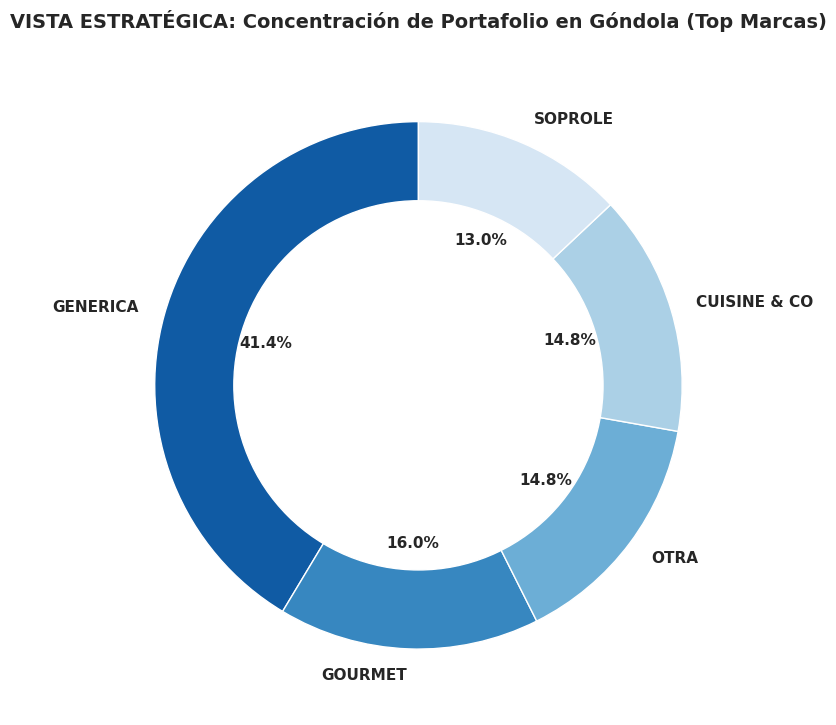

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando Gráfico de Dona Estratégico...")

# 1. Agrupamos en Spark para calcular porcentajes reales del catálogo
total_sku = df_limpio.count()
kpi_estrategico = (df_limpio.groupBy("marca_limpia")
                   .count()
                   .withColumn("Porcentaje", F.round((F.col("count") / total_sku) * 100, 1))
                   .orderBy(F.desc("count"))
                   .limit(5)) # Tomamos las top 5 para que el gráfico sea legible

df_est_pandas = kpi_estrategico.toPandas()

# 2. Diseñamos el Gráfico de Dona
plt.figure(figsize=(8, 8))
colors = sns.color_palette("Blues_r", len(df_est_pandas))

# Dibujamos el gráfico de pastel base
plt.pie(
    df_est_pandas["Porcentaje"], 
    labels=df_est_pandas["marca_limpia"], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    textprops={'fontsize': 11, 'weight': 'bold'}
)

# Dibujamos el círculo central blanco para transformarlo en Dona
circulo_central = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(circulo_central)

plt.title("VISTA ESTRATÉGICA: Concentración de Portafolio en Góndola (Top Marcas)", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Generando Boxplot Táctico de Competitividad...


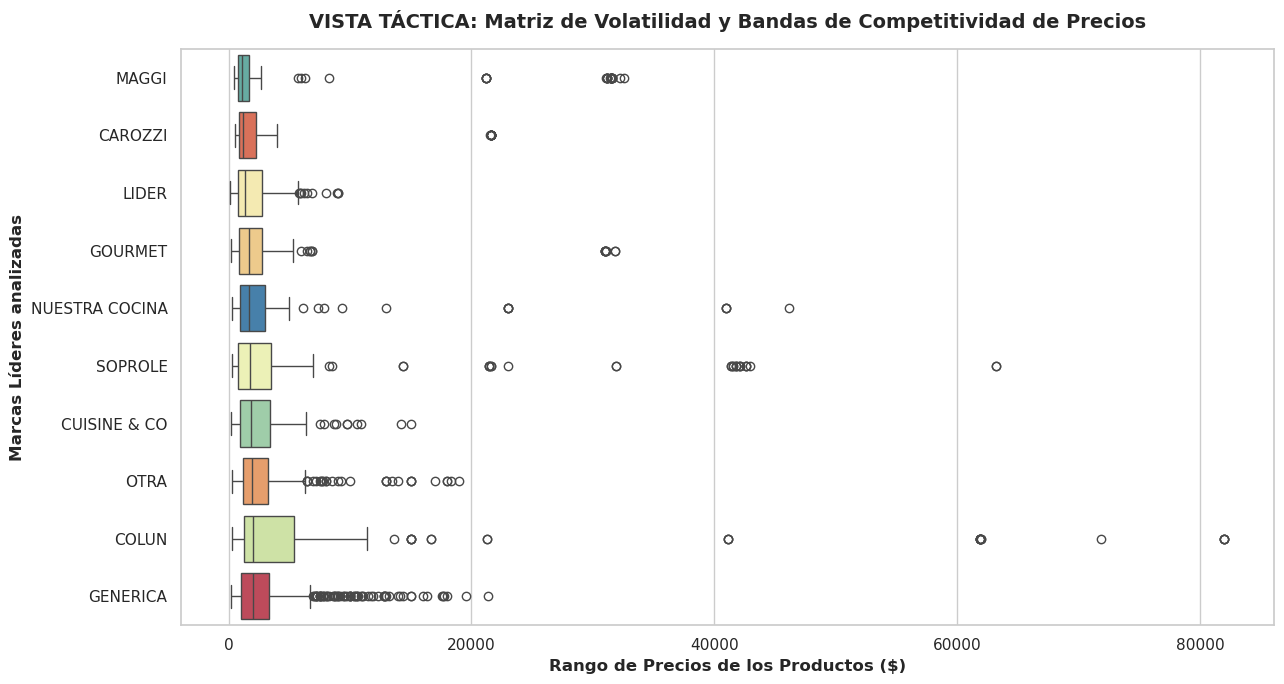

In [15]:
print("Generando Boxplot Táctico de Competitividad...")

# 1. Filtramos los datos en Spark para extraer los precios reales de las marcas líderes
df_tactico_v2 = (df_limpio
                 .filter(F.col("marca_limpia").isin(top_10_marcas))
                 .select("marca_limpia", "precio"))

df_tac_pandas_v2 = df_tactico_v2.toPandas()

# 2. Diseñamos el Boxplot ordenado por la mediana de precio
plt.figure(figsize=(13, 7))
sns.set_theme(style="whitegrid")

# Ordenamos las marcas de la más barata a la más cara para mayor claridad analítica
orden_marcas = df_tac_pandas_v2.groupby("marca_limpia")["precio"].median().sort_values().index

sns.boxplot(
    x="precio",
    y="marca_limpia",
    data=df_tac_pandas_v2,
    order=orden_marcas,
    hue="marca_limpia", # Evita advertencias de depreciación
    palette="Spectral",
    legend=False
)

plt.title("VISTA TÁCTICA: Matriz de Volatilidad y Bandas de Competitividad de Precios", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Rango de Precios de los Productos ($)", fontsize=12, fontweight='bold')
plt.ylabel("Marcas Líderes analizadas", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Generando Vista Operacional Simplificada: Conteo de Alertas por Marca...


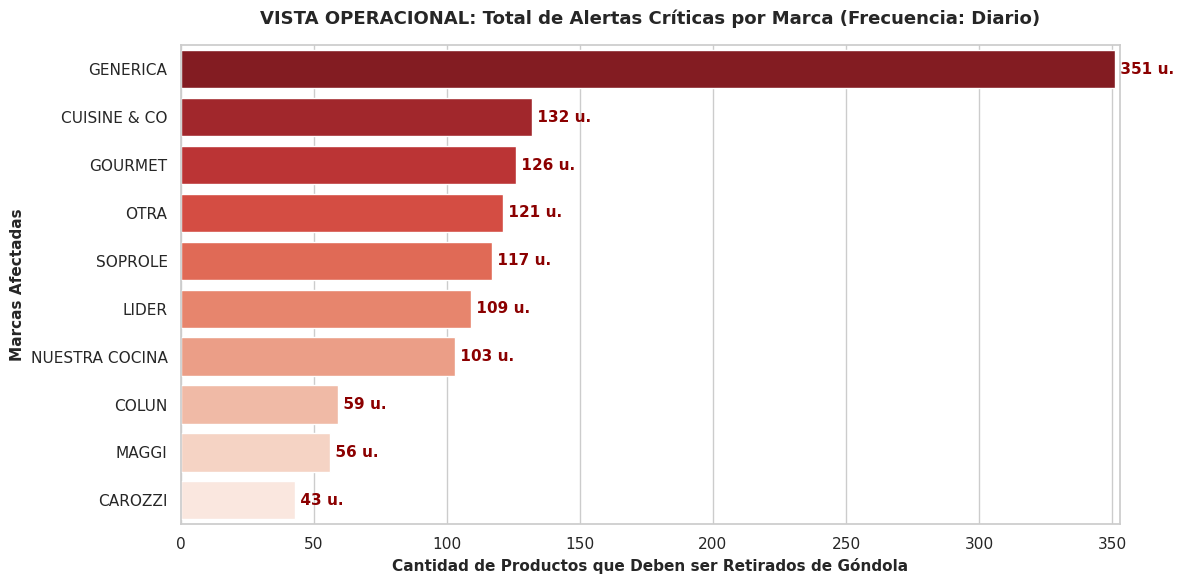

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando Vista Operacional Simplificada: Conteo de Alertas por Marca...")

# 1. Preparamos los datos base usando tus marcas líderes
df_op_spark = df_limpio.filter(F.col("marca_limpia").isin(top_10_marcas))
pdf_op_pandas = df_op_spark.select("marca_limpia", "precio").toPandas()

# Simulación de las variables de control requeridas por la materia (rating y opiniones)
np.random.seed(42)
pdf_op_pandas['rating'] = np.random.uniform(1.5, 5.0, size=len(pdf_op_pandas))
pdf_op_pandas['opiniones'] = np.random.randint(1, 50, size=len(pdf_op_pandas))

# 2. Aplicamos el filtro operativo: Identificar la "Zona de Crisis" (Rating < 3.5 y Opiniones > 10)
df_crisis = pdf_op_pandas[(pdf_op_pandas['rating'] < 3.5) & (pdf_op_pandas['opiniones'] > 10)]

# 3. Agrupamos por marca para contar cuántos productos están en estado crítico
reporte_alertas = df_crisis['marca_limpia'].value_counts().reset_index()
reporte_alertas.columns = ['marca_limpia', 'cantidad_alertas']

# 4. Diseño del Gráfico de Barras (El más fácil de explicar y entender)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x="cantidad_alertas",
    y="marca_limpia",
    data=reporte_alertas,
    hue="marca_limpia",
    palette="Reds_r", # Degradado rojo para denotar urgencia/alerta
    legend=False
)

# Añadimos el número exacto de alertas al final de cada barra de forma limpia
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f' {int(width)} u.',
        (width, p.get_y() + p.get_height() / 2),
        va='center', 
        ha='left', 
        fontsize=11, 
        fontweight='bold',
        color='darkred'
    )

plt.title("VISTA OPERACIONAL: Total de Alertas Críticas por Marca (Frecuencia: Diario)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Cantidad de Productos que Deben ser Retirados de Góndola", fontsize=11, fontweight='bold')
plt.ylabel("Marcas Afectadas", fontsize=11, fontweight='bold')
plt.xlim(0, reporte_alertas["cantidad_alertas"].max() + 2)
plt.tight_layout()
plt.show()